In [3]:
import numpy as np
import matplotlib.pyplot as plt

V_mod_tilde = 1
excess_noise=0.02
tau = np.arange(0.02, 0.84, 0.02, dtype=np.float32) #transmitância (40 pontos)
#tau = np.linspace(0.02, 0.32, 11).reshape(-1,1)
D = -np.log10(tau)*(10/0.2) # tau = 10^(-alpha*d/10), alpha is the fiber attenuation in dB/km. d = -log10(tau)*10/alpha
V_mod = 4 * V_mod_tilde # it is the variance of the quadrature operator, having a factor of 4 over the variance of the modulating classical random variable

#SNRdB_list = np.linspace(-10, 0, 10)
#SNR_list = 10**(SNRdB_list/10)
SNR_list = (tau * (V_mod) / (1 + excess_noise)).astype(np.float32)
SNRdB_list = (10 * np.log10(SNR_list)).astype(np.float32)

BER = np.loadtxt("Ber.txt", dtype=np.float32)
BER02 = np.loadtxt("Ber_unmatched02.txt", dtype=np.float32)
BER05 = np.loadtxt("Ber_unmatched05.txt", dtype=np.float32)
BER_02 = np.loadtxt("Ber_unmatched-02.txt", dtype=np.float32)

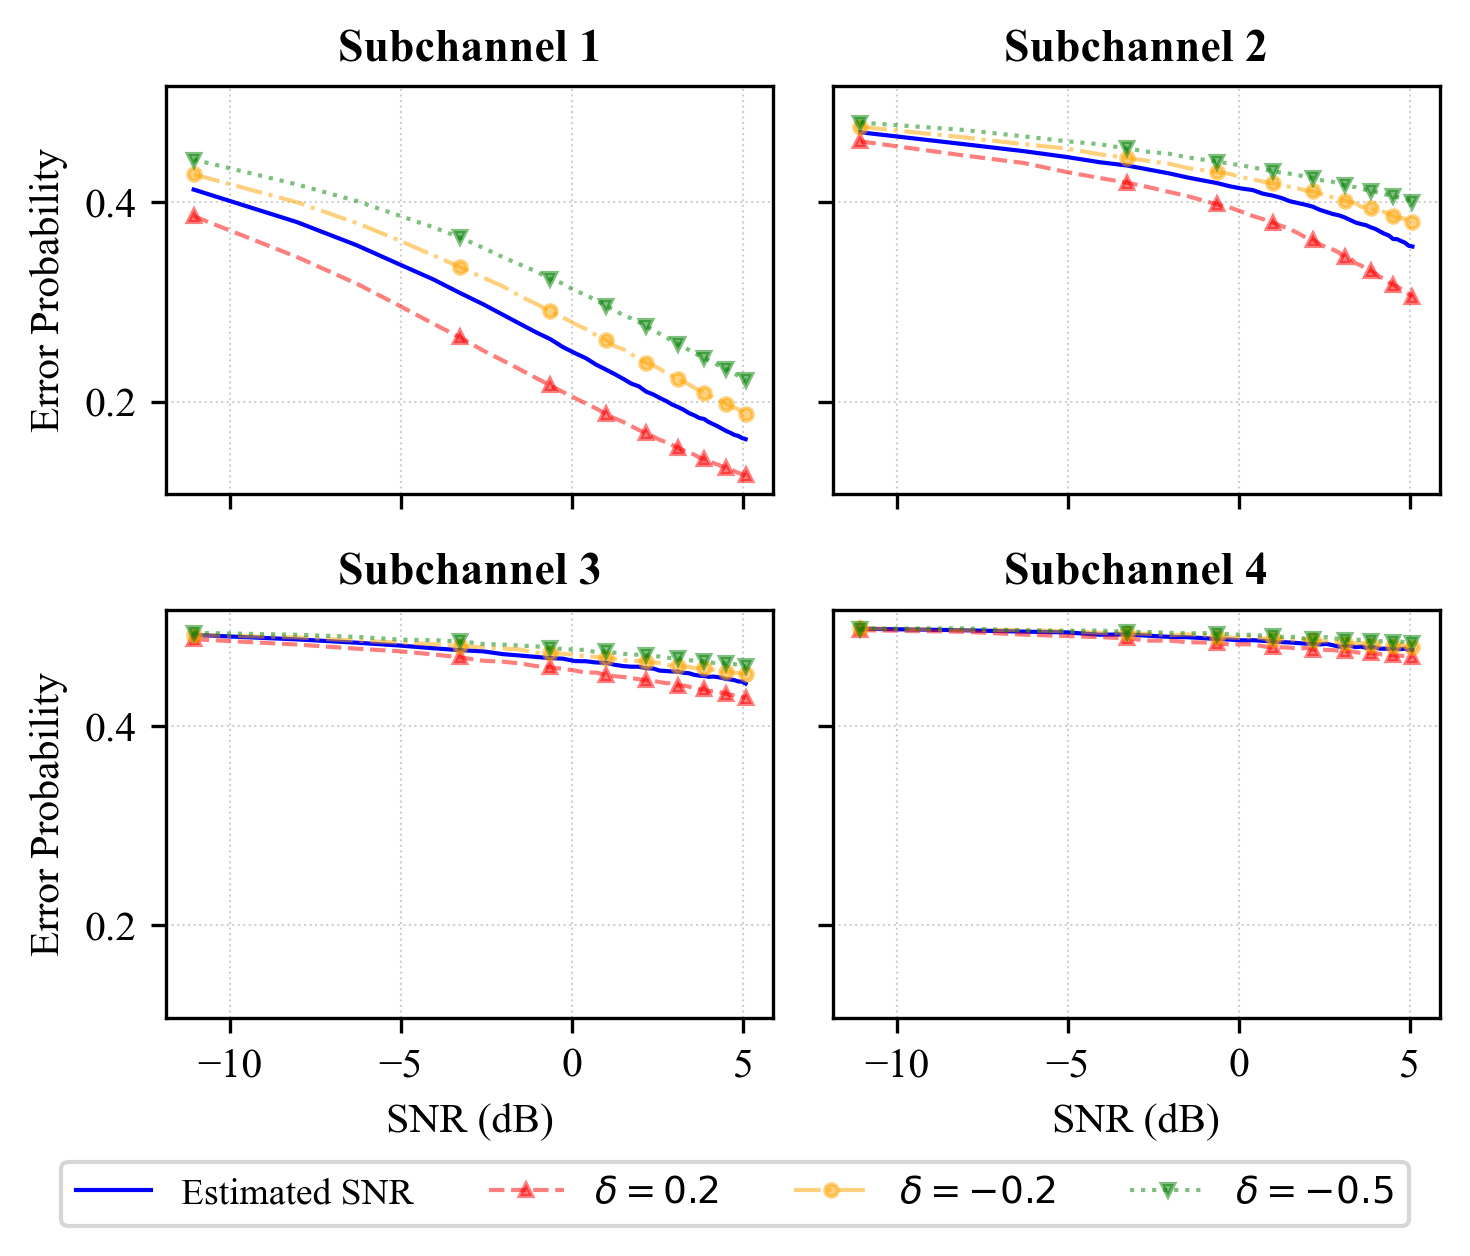

In [19]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # padrão comum em artigos
    "text.usetex": False,  # coloque True se tiver LaTeX instalado
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.0,
    "lines.markersize": 3,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "figure.figsize": (5, 4),  # ideal para coluna simples (~IEEE)
    "figure.dpi": 300
})


# Criando a grade 2x2 com eixos compartilhados
fig, axs = plt.subplots(2, 2, figsize=(5, 4), sharex=True, sharey=True)
subchannels = ['Subchannel 1', 'Subchannel 2', 'Subchannel 3', 'Subchannel 4']
#mismatches = ['Esimated SNR', 'Mismatch: +0.2', 'Mismatch: +0.2', 'Mismatch: +0.5']
mismatches = ['Estimated SNR', rf'$\delta=0.2$', rf'$\delta=-0.2$', rf'$\delta=-0.5$']
styles = ['-', '--', '-.', ':']
colors = ['blue', 'red', 'orange', 'green']
alphas = 0.5
markers = [None, '^', 'o', 'v']
snr_axis = SNRdB_list

BER = np.loadtxt("Ber.txt", dtype=np.float32)
BER02 = np.loadtxt("Ber_unmatched02.txt", dtype=np.float32)
BER05 = np.loadtxt("Ber_unmatched05.txt", dtype=np.float32)
BER_02 = np.loadtxt("Ber_unmatched-02.txt", dtype=np.float32)

for ch_idx, ax in enumerate(axs.flat):
    
    # Aqui acontece a mágica: o ch_idx (0, 1, 2 ou 3) escolhe a coluna exata 
    # de dentro de cada uma das suas 4 variáveis de descasamento.
    
    # Linha 1: Exata (Coluna ch_idx)
    ax.plot(snr_axis, BER[:, ch_idx], 
            linestyle=styles[0], marker=markers[0], color=colors[0], label=mismatches[0])
    
    # Linha 2: Mismatch +0.2 (Coluna ch_idx)
    ax.plot(snr_axis, BER_02[:, ch_idx], 
            linestyle=styles[1], marker=markers[1], markevery=5, color=colors[1], alpha=alphas, label=mismatches[1])
    
    # Linha 3: Mismatch +0.5 (Coluna ch_idx)
    ax.plot(snr_axis, BER02[:, ch_idx], 
            linestyle=styles[2], marker=markers[2], markevery=5, color=colors[2], alpha=alphas, label=mismatches[2])
    
    # Linha 4: Mismatch -0.2 (Coluna ch_idx)
    ax.plot(snr_axis, BER05[:, ch_idx], 
            linestyle=styles[3], marker=markers[3], markevery=5, color=colors[3], alpha=alphas, label=mismatches[3])
    
    # Customizações por subplot
    ax.set_title(subchannels[ch_idx], fontsize=11, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

# --- 4. AJUSTES FLUIDOS DE LAYOUT ---
# Labels apenas nas bordas externas de forma automática
for ax in axs[-1, :]: ax.set_xlabel('SNR (dB)')
for ax in axs[:, 0]: ax.set_ylabel('Error Probability')

# Adicionando labels apenas nas bordas externas devido ao sharex/sharey
for ax in axs[-1, :]: ax.set_xlabel('SNR (dB)')
for ax in axs[:, 0]: ax.set_ylabel('Error Probability')

# Cria uma legenda única para toda a figura, posicionada na parte inferior
fig.legend(mismatches, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4)
plt.tight_layout()

#Tentar escrever em termos da divergência KL

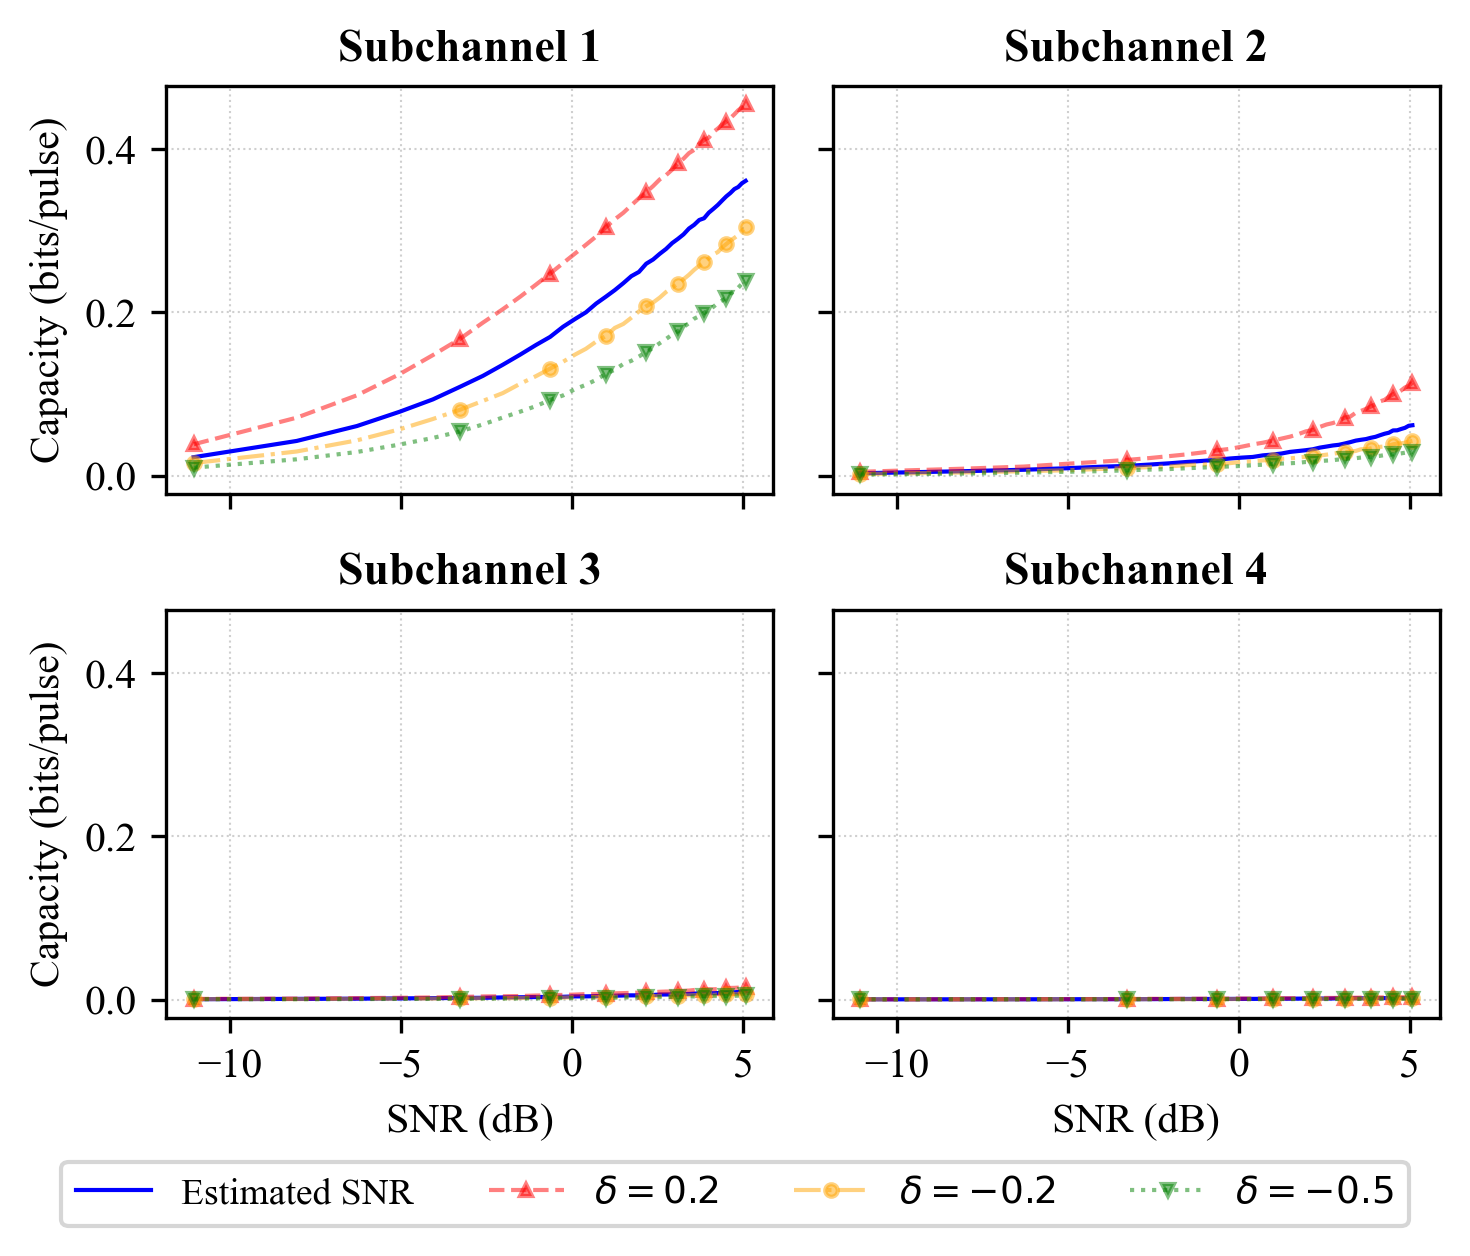

In [20]:
# Criando a grade 2x2 com eixos compartilhados
fig, axs = plt.subplots(2, 2, figsize=(5, 4), sharex=True, sharey=True)
subchannels = ['Subchannel 1', 'Subchannel 2', 'Subchannel 3', 'Subchannel 4']
#mismatches = ['Exact SNR', 'Mismatch: -0.2', 'Mismatch: +0.2', 'Mismatch: +0.5']
mismatches = ['Estimated SNR', rf'$\delta=0.2$', rf'$\delta=-0.2$', rf'$\delta=-0.5$']
styles = ['-', '--', '-.', ':']
colors = ['blue', 'red', 'orange', 'green']
alphas = 0.5
markers = [None, '^', 'o', 'v']
snr_axis = SNRdB_list

Capacity = np.loadtxt("Capacidade.txt", dtype=np.float32)
Capacity02 = np.loadtxt("Capacidade_unmatched02.txt", dtype=np.float32)
Capacity05 = np.loadtxt("Capacidade_unmatched05.txt", dtype=np.float32)
Capacity_02 = np.loadtxt("Capacidade_unmatched-02.txt", dtype=np.float32)

for ch_idx, ax in enumerate(axs.flat):
    
    # Aqui acontece a mágica: o ch_idx (0, 1, 2 ou 3) escolhe a coluna exata 
    # de dentro de cada uma das suas 4 variáveis de descasamento.
    
    # Linha 1: Exata (Coluna ch_idx)
    ax.plot(snr_axis, Capacity[:, ch_idx], 
            linestyle=styles[0], marker=markers[0], color=colors[0], label=mismatches[0])
    
    # Linha 2: Mismatch -0.2 (Coluna ch_idx)
    ax.plot(snr_axis, Capacity_02[:, ch_idx], 
            linestyle=styles[1], marker=markers[1], markevery=5, color=colors[1], alpha=alphas, label=mismatches[1])
    
    # Linha 3: Mismatch +0.2 (Coluna ch_idx)
    ax.plot(snr_axis, Capacity02[:, ch_idx], 
            linestyle=styles[2], marker=markers[2], markevery=5, color=colors[2], alpha=alphas, label=mismatches[2])
    
    # Linha 4: Mismatch +0.5 (Coluna ch_idx)
    ax.plot(snr_axis, Capacity05[:, ch_idx], 
            linestyle=styles[3], marker=markers[3], markevery=5, color=colors[3], alpha=alphas, label=mismatches[3])
    
    # Customizações por subplot
    ax.set_title(subchannels[ch_idx], fontsize=11, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

# --- 4. AJUSTES FLUIDOS DE LAYOUT ---
# Labels apenas nas bordas externas de forma automática
for ax in axs[-1, :]: ax.set_xlabel('SNR (dB)')
for ax in axs[:, 0]: ax.set_ylabel('Error Probability')

# Adicionando labels apenas nas bordas externas devido ao sharex/sharey
for ax in axs[-1, :]: ax.set_xlabel('SNR (dB)')
for ax in axs[:, 0]: ax.set_ylabel('Capacity (bits/pulse)')

# Cria uma legenda única para toda a figura, posicionada na parte inferior
fig.legend(mismatches, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4)
plt.tight_layout()

#Tentar escrever em termos da divergência KL

[-11.055101    -8.044802    -6.2838893   -5.0345016   -4.065402
  -3.2735896   -2.6041212   -2.0242019   -1.5126771   -1.0551021
  -0.64117527  -0.26328936   0.08433142   0.4061787    0.7058109
   0.9860981    1.2493875    1.4976233    1.7324342    1.9551982
   2.1670911    2.3691251    2.5621767    2.7470107    2.9242983
   3.0946314    3.2585356    3.4164784    3.568878     3.7161107
   3.8585148    3.9963982    4.1300373    4.259687     4.3855786
   4.5079226    4.626915     4.742734     4.855544     4.965498
   5.0727367 ]
Iteration global: 0
Iteration global: 1
Iteration global: 2
Iteration global: 3
Iteration global: 4
Iteration global: 5
Iteration global: 6
Iteration global: 7
Iteration global: 8
Iteration global: 9


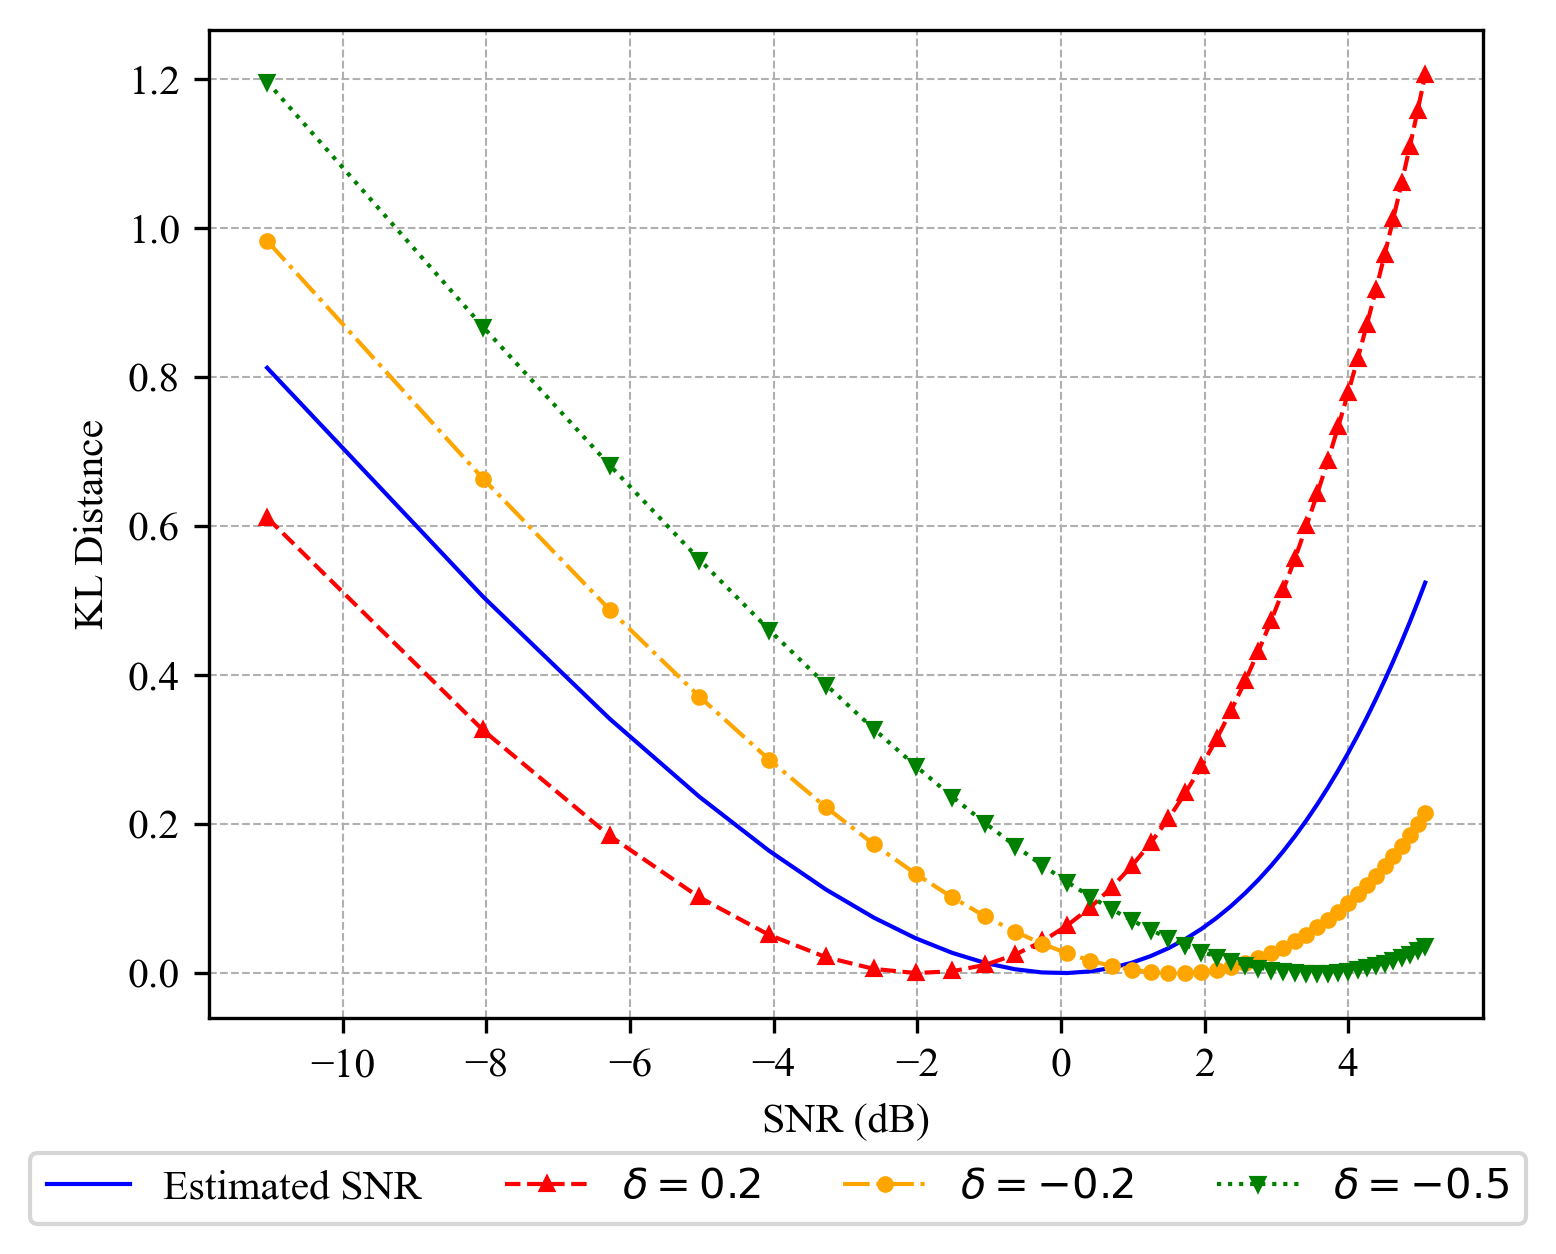

In [21]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # padrão comum em artigos
    "text.usetex": False,  # coloque True se tiver LaTeX instalado
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.0,
    "lines.markersize": 3,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "figure.figsize": (5, 4),  # ideal para coluna simples (~IEEE)
    "figure.dpi": 300
})


#KL distance between two Gaussian Distributions with the same mean and different variances

V_mod_tilde = 1
excess_noise=0.02
tau = np.arange(0.02, 0.84, 0.02, dtype=np.float32) #transmitância (40 pontos)
#tau = np.linspace(0.02, 0.32, 11).reshape(-1,1)
D = -np.log10(tau)*(10/0.2) # tau = 10^(-alpha*d/10), alpha is the fiber attenuation in dB/km. d = -log10(tau)*10/alpha
V_mod = 4 * V_mod_tilde # it is the variance of the quadrature operator, having a factor of 4 over the variance of the modulating classical random variable

SNR_list = (tau * (V_mod) / (1 + excess_noise)).astype(np.float32)
SNRdB_list = (10 * np.log10(SNR_list)).astype(np.float32)
#I_gaussian = np.log2(1 + SNR_lin)/2
print(SNRdB_list)

snrs = tau.size

mu0 = 0
sigma = 1

realizacoes = 1000
max_iterations = 10

KL_sum = np.zeros(snrs, dtype=np.float32)

KL_sum_02 = np.zeros(snrs, dtype=np.float32)
KL_sum02 = np.zeros(snrs, dtype=np.float32)
KL_sum05 = np.zeros(snrs, dtype=np.float32)

for iterations in range(0, max_iterations):

    print(f"Iteration global: {iterations}")

    #M = np.random.normal(mu0, sigma, (100000, 1)).astype(np.float32)
    #Gaussian values of Alice
    #x = M

    for glob in range(0, snrs):
        #sigmar = sigma / np.sqrt(SNR_list[glob])
        #Mr = np.random.normal(mu0, sigmar, (100000, 1)) #ruído

        sigmar = np.sqrt((1+excess_noise)/(tau[glob]*4))
        sigmar_02 = sigmar - 0.2*sigmar
        sigmar02 = sigmar + 0.2*sigmar
        sigmar05 = sigmar + 0.5*sigmar

        #Mr = np.random.normal(mu0, sigmar, (100000, 1)).astype(np.float32) #ruído

        #Valores de Bob
        #y = M + Mr
        
        KL_distance = np.log(sigmar/sigma) + (sigma**2)/(2 * sigmar**2) - 1/2

        KL_distance_02 = np.log(sigmar_02/sigma) + (sigma**2)/(2 * sigmar_02**2) - 1/2
        KL_distance02 = np.log(sigmar02/sigma) + (sigma**2)/(2 * sigmar02**2) - 1/2
        KL_distance05 = np.log(sigmar05/sigma) + (sigma**2)/(2 * sigmar05**2) - 1/2

        KL_sum[glob] += KL_distance

        KL_sum_02[glob] += KL_distance_02
        KL_sum02[glob] += KL_distance02
        KL_sum05[glob] += KL_distance05


KL_mean = KL_sum/max_iterations

KL_mean_02 = KL_sum_02/max_iterations
KL_mean02 = KL_sum02/max_iterations
KL_mean05 = KL_sum05/max_iterations

mismatches = ['Estimated SNR', rf'$\delta=0.2$', rf'$\delta=-0.2$', rf'$\delta=-0.5$']

fig, ax1 = plt.subplots()

ax1.plot(SNRdB_list, KL_mean, linestyle=styles[0], marker=markers[0], color=colors[0], label=mismatches[0])
ax1.plot(SNRdB_list, KL_mean_02, linestyle=styles[1], marker=markers[1], color=colors[1], label=mismatches[1])
ax1.plot(SNRdB_list, KL_mean02, linestyle=styles[2], marker=markers[2], color=colors[2], label=mismatches[2])
ax1.plot(SNRdB_list, KL_mean05, linestyle=styles[3], marker=markers[3], color=colors[3], label=mismatches[3])

ax1.set_xlabel('SNR (dB)')
ax1.set_ylabel('KL Distance')

fig.legend(mismatches, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4)
plt.tight_layout()
plt.show()

np.savetxt('KL_match.txt', KL_mean)

np.savetxt('KL_match_02.txt', KL_mean_02)
np.savetxt('KL_match02.txt', KL_mean02)
np.savetxt('KL_match05.txt', KL_mean05)

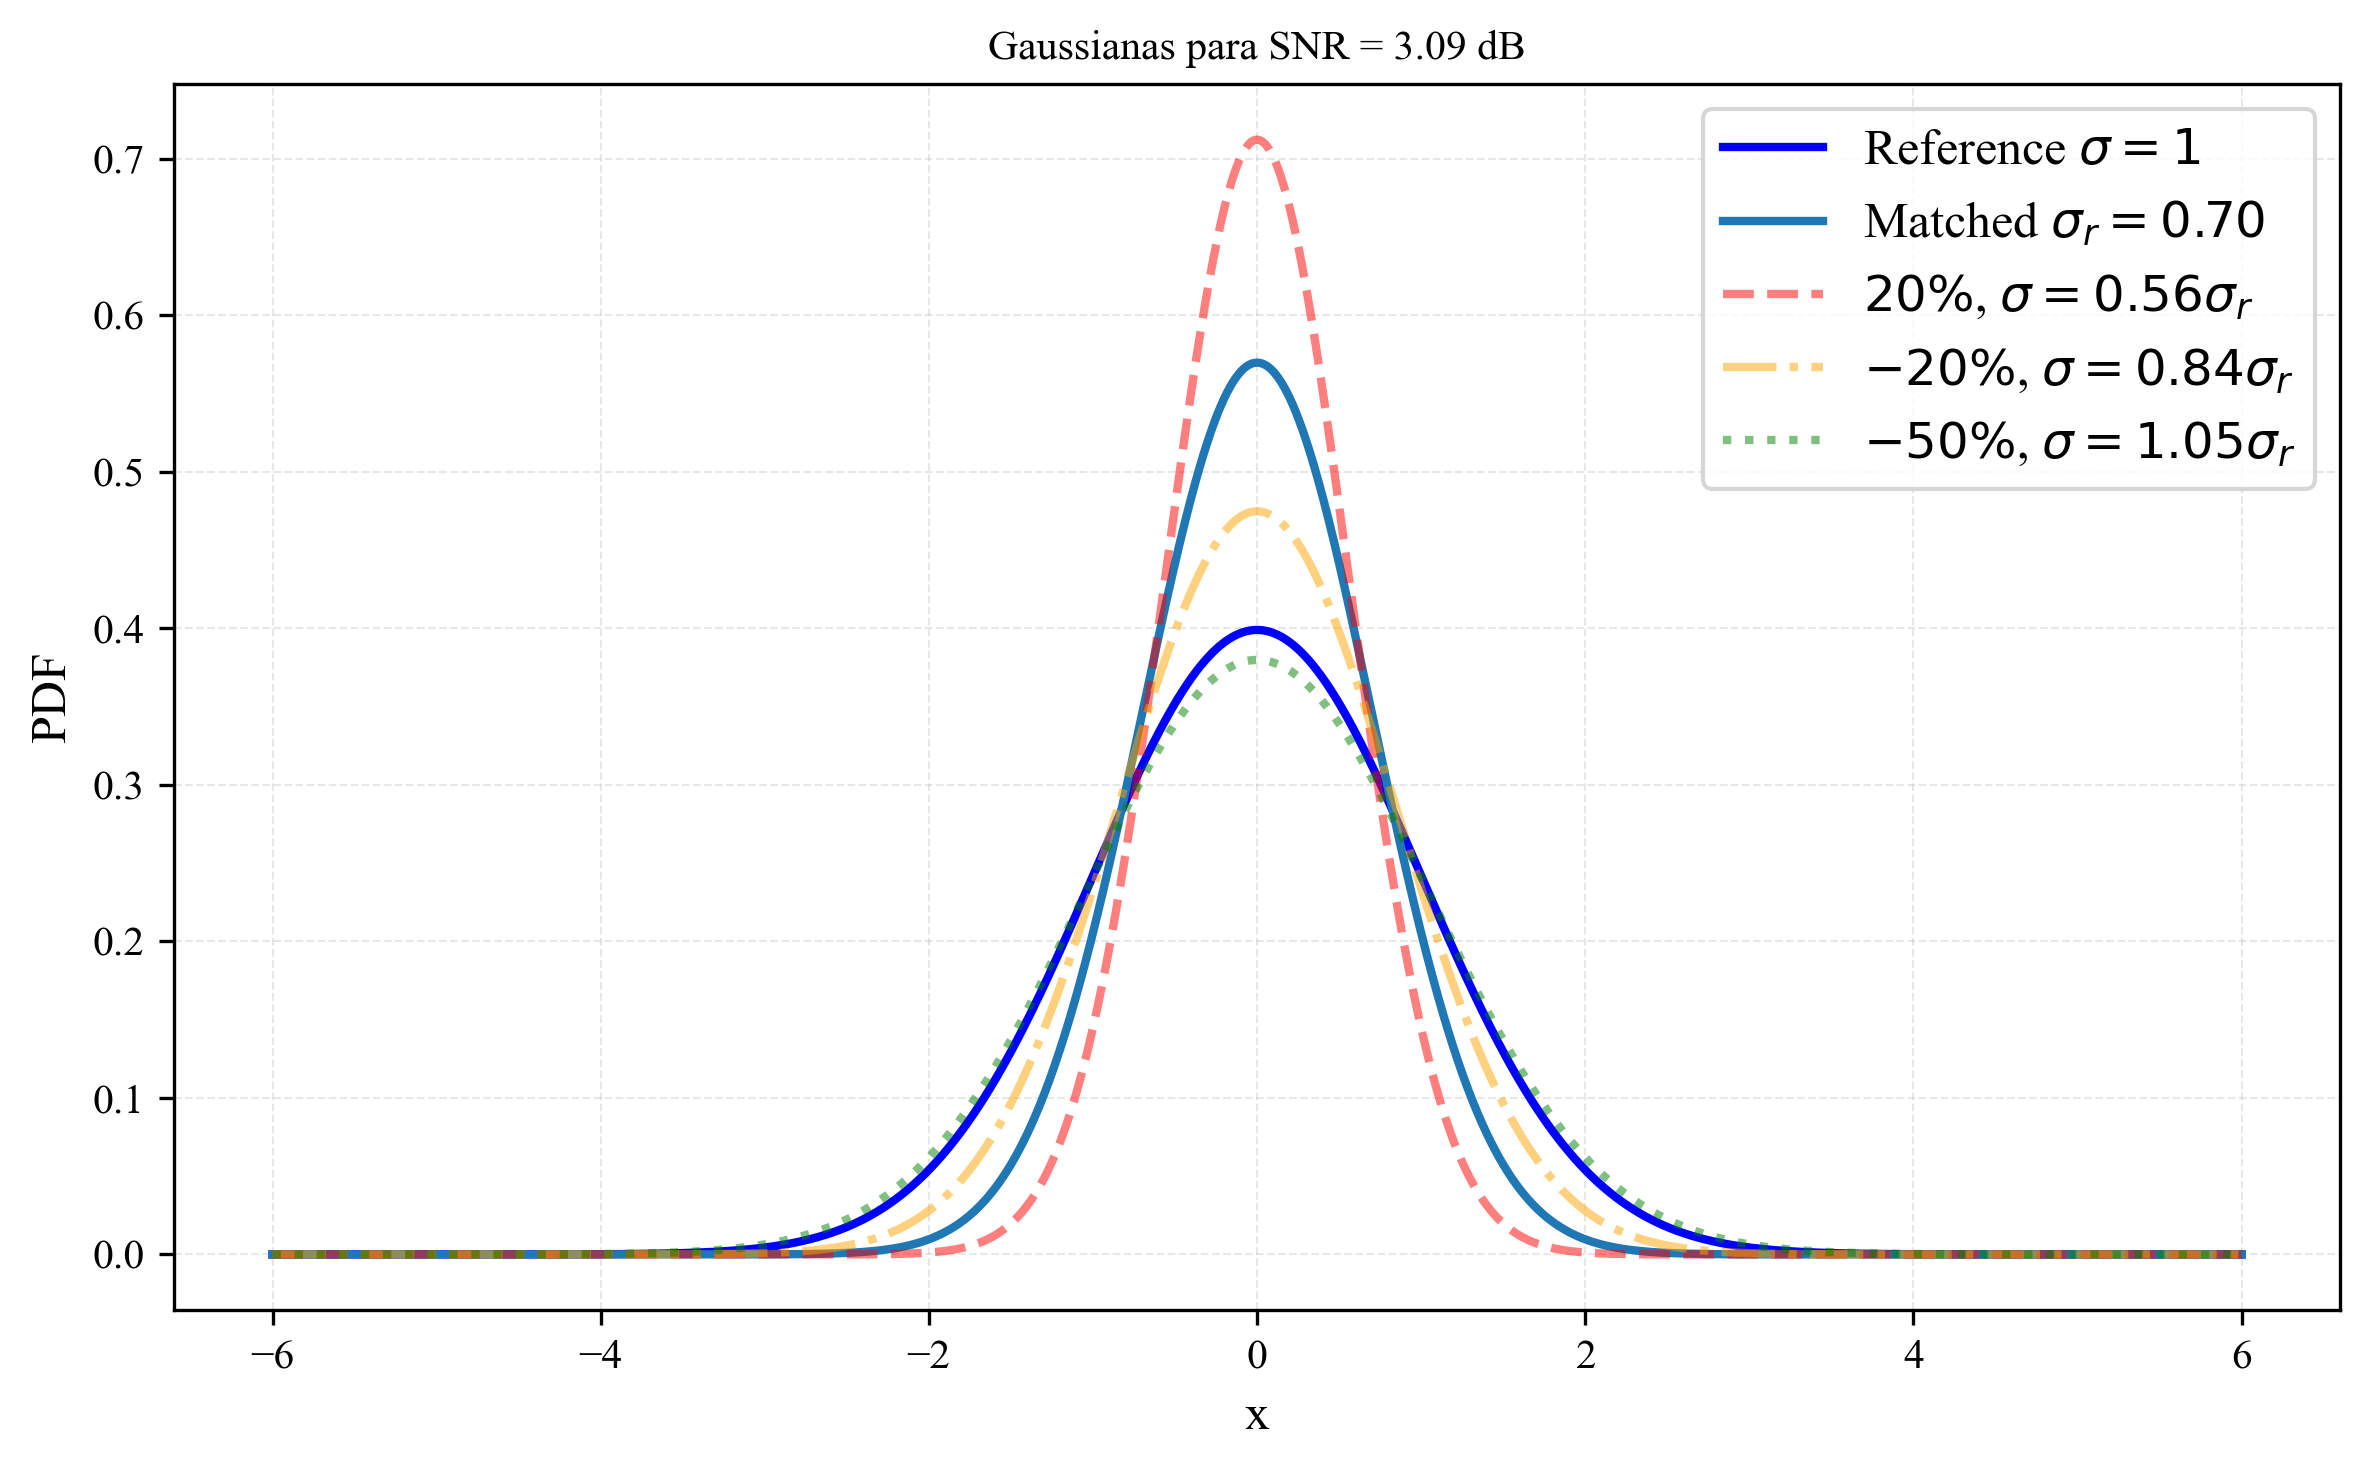

In [25]:
from scipy.stats import norm

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # padrão comum em artigos
    "text.usetex": False,  # coloque True se tiver LaTeX instalado
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 10,
    "legend.fontsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.0,
    "lines.markersize": 3,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "figure.figsize": (5, 4),  # ideal para coluna simples (~IEEE)
    "figure.dpi": 300
})

idx = 25

# Variâncias correspondentes
sigmar = np.sqrt((1 + excess_noise)/(tau[idx]*4))
sigmar_02 = sigmar - 0.2*sigmar
sigmar02 = sigmar + 0.2*sigmar
sigmar05 = sigmar + 0.5*sigmar

# Eixo x
x = np.linspace(-6, 6, 2000)

# PDFs gaussianas
pdf_ref = norm.pdf(x, mu0, sigma)

pdf_match = norm.pdf(x, mu0, sigmar)
pdf_m02 = norm.pdf(x, mu0, sigmar_02)
pdf_p02 = norm.pdf(x, mu0, sigmar02)
pdf_p05 = norm.pdf(x, mu0, sigmar05)

# PDFs gaussianas
pdf_ref = norm.pdf(x, mu0, sigma)

pdf_match = norm.pdf(x, mu0, sigmar)
pdf_m02 = norm.pdf(x, mu0, sigmar_02)
pdf_p02 = norm.pdf(x, mu0, sigmar02)
pdf_p05 = norm.pdf(x, mu0, sigmar05)

# Plot
plt.figure(figsize=(8,5))

plt.plot(x, pdf_ref,
         linewidth=2,
         linestyle=styles[0],
         color=colors[0],
         label=r'Reference $\sigma=1$')

plt.plot(x, pdf_match,
         linewidth=2,
         linestyle=styles[0],
         label=rf'Matched $\sigma_r={sigmar:.2f}$')

plt.plot(x, pdf_m02,
         linewidth=2,
         linestyle=styles[1],
         color=colors[1],
         alpha=0.5,
         label=rf'$20\%$, $\sigma={sigmar_02:.2f}\sigma_r$')

plt.plot(x, pdf_p02,
         linewidth=2,
         linestyle=styles[2],
         color=colors[2],
         alpha=0.5,
         label=rf'$-20\%$, $\sigma={sigmar02:.2f}\sigma_r$')

plt.plot(x, pdf_p05,
         linewidth=2,
         linestyle=styles[3],
         color=colors[3],
         alpha=0.5,
         label=rf'$-50\%$, $\sigma={sigmar05:.2f}\sigma_r$')

plt.xlabel('x')
plt.ylabel('PDF')
plt.title(f'Gaussianas para SNR = {SNRdB_list[idx]:.2f} dB')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()